### Problem 1: Logistic Regression

In [42]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

#feature names
feature_names = [
    'word_freq_make','word_freq_address','word_freq_all','word_freq_3d',
    'word_freq_our','word_freq_over','word_freq_remove','word_freq_internet',
    'word_freq_order','word_freq_mail','word_freq_receive','word_freq_will',
    'word_freq_people','word_freq_report','word_freq_addresses','word_freq_free',
    'word_freq_business','word_freq_email','word_freq_you','word_freq_credit',
    'word_freq_your','word_freq_font','word_freq_000','word_freq_money',
    'word_freq_hp','word_freq_hpl','word_freq_george','word_freq_650',
    'word_freq_lab','word_freq_labs','word_freq_telnet','word_freq_857',
    'word_freq_data','word_freq_415','word_freq_85','word_freq_technology',
    'word_freq_1999','word_freq_parts','word_freq_pm','word_freq_direct',
    'word_freq_cs','word_freq_meeting','word_freq_original','word_freq_project',
    'word_freq_re','word_freq_edu','word_freq_table','word_freq_conference',
    'char_freq_;','char_freq_(','char_freq_[','char_freq_!','char_freq_$',
    'char_freq_#','capital_run_length_average','capital_run_length_longest',
    'capital_run_length_total'
]

df = pd.read_csv('spambase.data', header=None)
df.columns = feature_names + ['spam']

X = df[feature_names].values
y = df['spam'].values

#train/test split (75/25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#a) confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("1) Model Evaluation on Test Set")

print("\na. confusion matrix:")
print(f"{'':20s} Predicted Not Spam  Predicted Spam")
print(f"{'Actual Not Spam':20s} {cm[0,0]:>17d}  {cm[0,1]:>13d}")
print(f"{'Actual Spam':20s} {cm[1,0]:>17d}  {cm[1,1]:>13d}")
print(f"\n   TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

#b) accuracy/error
acc = accuracy_score(y_test, y_pred)
err = 1 - acc
print(f"\nb. Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Error: {err:.4f}  ({err*100:.2f}%)")

#c) precision/recall/F1
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
print(f"\nc. Precision: {prec:.4f}")
print(f"   Recall: {rec:.4f}")
print(f"   F1 Score: {f1:.4f}")

#2) feature coefficients
print("2) Logistic Regression Coefficients")

coefs = pd.Series(model.coef_[0], index=feature_names)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

print("\nTop 10 most influential features (by |coefficient|):")
print(f"{'Feature':<40s} {'Coefficient':>12s}  Direction")

for feat, val in coefs_sorted.head(10).items():
    direction = "→ Spam (+)" if val > 0 else "→ Not-Spam (−)"
    print(f"{feat:<40s} {val:>12.4f}  {direction}")

pos = coefs[coefs > 0].sort_values(ascending=False)
neg = coefs[coefs < 0].sort_values()

print(f"\nPositively correlated with Spam ({len(pos)} features):")
for f, v in pos.head(8).items():
    print(f"  {f:<40s}  {v:+.4f}")

print(f"\nNegatively correlated with Spam ({len(neg)} features):")
for f, v in neg.head(8).items():
    print(f"  {f:<40s}  {v:+.4f}")

#3) Varying the decision threshold

print("3) Effect of Decision Threshold")

y_prob = model.predict_proba(X_test)[:, 1]
thresholds = [0.25, 0.5, 0.75, 0.9]

print(f"\n{'Threshold':>10s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s}")

for T in thresholds:
    y_t = (y_prob >= T).astype(int)
    a = accuracy_score(y_test, y_t)
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t, zero_division=0)
    print(f"{T:>10.2f} {a:>10.4f} {p:>10.4f} {r:>10.4f}")




1) Model Evaluation on Test Set

a. confusion matrix:
                     Predicted Not Spam  Predicted Spam
Actual Not Spam                    650             26
Actual Spam                         58            417

   TN=650  FP=26  FN=58  TP=417

b. Accuracy: 0.9270  (92.70%)
   Error: 0.0730  (7.30%)

c. Precision: 0.9413
   Recall: 0.8779
   F1 Score: 0.9085
2) Logistic Regression Coefficients

Top 10 most influential features (by |coefficient|):
Feature                                   Coefficient  Direction
word_freq_george                              -4.2269  → Not-Spam (−)
char_freq_$                                    3.0983  → Spam (+)
word_freq_000                                  2.4552  → Spam (+)
word_freq_remove                               2.3266  → Spam (+)
word_freq_hp                                  -1.7577  → Not-Spam (−)
word_freq_project                             -1.7443  → Not-Spam (−)
word_freq_meeting                             -1.7159  → Not-Spam (−)

3 continued:

- As T increases, fewer emails are classified as spam so precision rises
(when the model does predict spam, it's more confident and more often correct),
but Recall falls (many actual spam emails are missed).

- When T is low (<0.25) the model is aggressive and has high recall but low precision meaning more false positives so real emails get flagged as spam.

- Accuracy seems to peak near 0.5 and worsens at extremes.

- The tradeoff: raising T trades spam detection sensitivity for less false alarms,
and vice-versa.


Problem 2: Gradient Descent for Logistic Regression

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

train_df = pd.read_csv('train (1).csv')
test_df  = pd.read_csv('test (1).csv')

drop_cols  = ['Unnamed: 0', 'id', 'date', 'zipcode']
drop_cols2 = ['Unnamed: 0', 'zipcode']
train_df = train_df.drop(columns=[c for c in drop_cols2 if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in drop_cols  if c in test_df.columns])

#binary targets
median_price = train_df['price'].median()
y_train = (train_df['price'] > median_price).astype(int).values
y_test  = (test_df['price']  > median_price).astype(int).values

X_train_raw = train_df.drop(columns=['price'])
X_test_raw  = test_df.drop(columns=['price'])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

#bias column
m_train = X_train.shape[0]
m_test  = X_test.shape[0]
X_train_b = np.hstack((np.ones((m_train, 1)), X_train))
X_test_b  = np.hstack((np.ones((m_test,  1)), X_test))

#helper functions
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def cross_entropy_loss(X, y, theta):
    """Binary cross entropy loss."""
    m = X.shape[0]
    p = sigmoid(X.dot(theta))
    # Clip to avoid log(0)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

#this is adapted from hw2: Log Reg from GD
def train_logistic_gradient_descent(X, y, learning_rate, iterations,
                                    log_at=(10, 50, 100)):
    """
    Trains Log Reg using GD.
    Adapted from hw2 train_gradient_descent for linear regression.

    """
    m, n = X.shape
    theta = np.zeros(n)
    loss_log = {}

    for i in range(1, iterations + 1):

        predictions = sigmoid(X.dot(theta))

        errors = predictions - y

        gradient = (1 / m) * X.T.dot(errors)

        theta = theta - learning_rate * gradient

        if i in log_at:
            loss_log[i] = cross_entropy_loss(X, y, theta)

    return theta, loss_log

def predict(X, theta, threshold=0.5):
    return (sigmoid(X.dot(theta)) >= threshold).astype(int)

def metrics(y_true, y_pred, label=""):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    if label:
        print(f"  {label:<20s}  Acc={acc:.4f}  Prec={prec:.4f}  "
              f"Rec={rec:.4f}  F1={f1:.4f}")
    return acc, prec, rec, f1

#experiment
learning_rates = [0.01, 0.1, 0.5]
log_iters      = (10, 50, 100)

print("Part A: Cross-Entropy Loss at 10, 50, and 100 Iterations")

print(f"\n{'Alpha':<8} {'Iter 10':>12} {'Iter 50':>12} {'Iter 100':>12}")

results = {}
for alpha in learning_rates:
    theta, loss_log = train_logistic_gradient_descent(
        X_train_b, y_train, alpha, 100, log_at=log_iters)
    results[alpha] = (theta, loss_log)
    print(f"{alpha:<8} {loss_log[10]:>12.6f} {loss_log[50]:>12.6f} {loss_log[100]:>12.6f}")

print("Part B: Classification Metrics at 100 Iterations")

for alpha in learning_rates:
    theta, _ = results[alpha]
    print(f"\n  Learning rate alpha = {alpha}")
    y_pred_train = predict(X_train_b, theta)
    y_pred_test  = predict(X_test_b,  theta)
    metrics(y_train, y_pred_train, "Train")
    metrics(y_test,  y_pred_test,  "Test")

#sklearn comparison
print("Part C: sklearn Log Reg Baseline (lbfgs, max_iter=1000)")

sk_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
sk_model.fit(X_train, y_train)
y_sk_train = sk_model.predict(X_train)
y_sk_test  = sk_model.predict(X_test)

print("\n  sklearn (converged):")
metrics(y_train, y_sk_train, "Train")
metrics(y_test,  y_sk_test,  "Test")

#comparison table
print("Summary Table: Test Set Metrics at 100 Iterations vs sklearn")
print(f"\n{'Method':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")

for alpha in learning_rates:
    theta, _ = results[alpha]
    y_pred = predict(X_test_b, theta)
    a, p, r, f = metrics(y_test, y_pred)
    print(f"  GD alpha={alpha:<5} (100 iter)  {a:>10.4f} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

a, p, r, f = metrics(y_test, y_sk_test)
print(f"  sklearn (converged)       {a:>10.4f} {p:>10.4f} {r:>10.4f} {f:>10.4f}")



Part A: Cross-Entropy Loss at 10, 50, and 100 Iterations

Alpha         Iter 10      Iter 50     Iter 100
0.01         0.658553     0.570309     0.512445
0.1          0.510017     0.383036     0.347371
0.5          0.379766     0.322642     0.315333
Part B: Classification Metrics at 100 Iterations

  Learning rate alpha = 0.01
  Train                 Acc=0.8060  Prec=0.8545  Rec=0.7339  F1=0.7896
  Test                  Acc=0.8040  Prec=0.8657  Rec=0.7532  F1=0.8056

  Learning rate alpha = 0.1
  Train                 Acc=0.8480  Prec=0.8644  Rec=0.8226  F1=0.8430
  Test                  Acc=0.8340  Prec=0.8580  Rec=0.8293  F1=0.8434

  Learning rate alpha = 0.5
  Train                 Acc=0.8540  Prec=0.8500  Rec=0.8569  F1=0.8534
  Test                  Acc=0.8390  Prec=0.8553  Rec=0.8442  F1=0.8497
Part C: sklearn Log Reg Baseline (lbfgs, max_iter=1000)

  sklearn (converged):
  Train                 Acc=0.8520  Prec=0.8537  Rec=0.8468  F1=0.8502
  Test                  Acc=0.8430  

Observations:
  1. Loss convergence: Higher learning rates (0.1, 0.5) reduce the
  cross-entropy loss faster in early iterations (10, 50) compared to
  a learning rate of 0.01, which converges slowly. but a learning rate of 0.5 risks fluctuation if the loss does not decrease steadily.

  2. Metrics vs iterations: At only 10 iterations, small learning rate (0.01) has
  not yet converged, accuracy/F1 are  lower. By 100 iterations, larger learning rates approach sklearn's performance.

  3. GD vs sklearn: sklearn uses a full     L-BFGS optimizer run to convergence. Our 100-iteration GD with a learning rate of 0.1 or 0.5 comes close but may still trail a bit in accuracy and F1 due to under convergence.

  4. Precision/Recall trade-off is stable across learning rates at 100 iterations, confirming the model has found a solid decision boundary regardless of step size.


### Problem 3: Comparing classifiers

In [44]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.model_selection import train_test_split

#same split as problem 1
feature_names = []
with open('spambase.names') as f:
    for line in f:
        line = line.strip()
        if not line.startswith('|') and ':' in line and \
                ('continuous' in line or 'nominal' in line):
            feature_names.append(line.split(':')[0].strip())

df = pd.read_csv('spambase.data', header=None)
df.columns = feature_names + ['spam']

X = df[feature_names].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

def report(y_true, y_pred, label=""):
    acc  = accuracy_score(y_true, y_pred)
    err  = 1 - acc
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    if label:
        print(f"  {label:<22s}  Acc={acc:.4f}  Err={err:.4f}  "
              f"Prec={prec:.4f}  Rec={rec:.4f}")
    return acc, err, prec, rec

#1) CV to select k for kNN
print("1) kNN Cross-Validation (5-fold) to select k")

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print(f"\n{'k':<6} {'CV Acc':>8} {'CV Err':>8} {'CV Prec':>9} {'CV Rec':>8}")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    acc_scores  = cross_val_score(knn, X_train, y_train, cv=cv, scoring='accuracy')
    prec_scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring='precision')
    rec_scores  = cross_val_score(knn, X_train, y_train, cv=cv, scoring='recall')
    mean_acc  = acc_scores.mean()
    mean_err  = 1 - mean_acc
    mean_prec = prec_scores.mean()
    mean_rec  = rec_scores.mean()
    cv_results[k] = (mean_acc, mean_err, mean_prec, mean_rec)
    print(f"{k:<6} {mean_acc:>8.4f} {mean_err:>8.4f} {mean_prec:>9.4f} {mean_rec:>8.4f}")

best_k = min(cv_results, key=lambda k: cv_results[k][1])
print(f"\n→ Best k = {best_k}  (lowest CV error = {cv_results[best_k][1]:.4f})")

#2) Train all 3 classifiers, report metrics on train/test
print("2) Classifier Comparison: Train & Test Metrics")

lr  = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)
lda = LinearDiscriminantAnalysis()
knn = KNeighborsClassifier(n_neighbors=best_k)

lr.fit(X_train, y_train)
lda.fit(X_train, y_train)
knn.fit(X_train, y_train)

classifiers = [("Logistic Regression", lr),
               ("LDA",                 lda),
               ("kNN (k=%d)" % best_k, knn)]

all_metrics = {}
for name, clf in classifiers:
    print(f"\n  [{name}]")
    tr_metrics = report(y_train, clf.predict(X_train), "Train")
    te_metrics = report(y_test,  clf.predict(X_test),  "Test ")
    all_metrics[name] = {"train": tr_metrics, "test": te_metrics}

print("""
Observations:
  - Logistic Regression and LDA are both linear classifiers so they usually
    perform similarly on data like Spambase. LDA also assumes gaussian/normal features
    with equal covariance
  - kNN is a non-parametric method that captures non linear boundaries
    At the optimal k it often achieves good/competitive accuracy.
  - A large gap between train and test accuracy signifies overfitting, whjich
    is pretty normal at small k for kNN).
  - The model with the highest test F1 and lowest test error is the best
    overall. the one trailing on test recall misses more spam emails.
""")

#3) ROC curve via sklearn + AUC  (Logistic Regression on test set)
print("3) ROC Curve (sklearn) + AUC for Logistic Regression")

y_scores = lr.predict_proba(X_test)[:, 1]
fpr_sk, tpr_sk, thresholds_sk = roc_curve(y_test, y_scores)
roc_auc = auc(fpr_sk, tpr_sk)
print(f"\n  AUC (sklearn ROC) = {roc_auc:.4f}")

#4) manual ROC curve (11 thresholds)

print("4) Manual ROC Curve (T ∈ {0, …, 1.0})")


manual_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                     0.6, 0.7, 0.8, 0.9, 1.0]
manual_fpr, manual_tpr = [], []

print(f"\n{'T':<6} {'FPR':>8} {'TPR':>8}")

for T in manual_thresholds:
    y_pred_t = (y_scores >= T).astype(int)
    TP = np.sum((y_pred_t == 1) & (y_test == 1))
    FP = np.sum((y_pred_t == 1) & (y_test == 0))
    TN = np.sum((y_pred_t == 0) & (y_test == 0))
    FN = np.sum((y_pred_t == 0) & (y_test == 1))
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    manual_fpr.append(fpr)
    manual_tpr.append(tpr)
    print(f"{T:<6.1f} {fpr:>8.4f} {tpr:>8.4f}")

manual_auc = np.trapezoid(manual_tpr[::-1], manual_fpr[::-1])
print(f"\n  AUC (manual, trapezoid) = {manual_auc:.4f}")
print(f"  AUC (sklearn) = {roc_auc:.4f}")
print("""

Comparison:
  - The sklearn ROC curve uses unique predicted probability values as
  thresholds, which producied a smooth curve that is similar the ROC boundary.

  - The manual curve uses only 11 thresholds, resulting in a
  rough step-wise estimation. The two curves share the same endpoints
  (0,0) and (1,1), but the manual version misses a lot of points
  between thresholds, causing its AUC estimate to differ.

  - To make the two curves more similar:
    1) Increase the number of manual thresholds
    2) Use the actual predicted probabilities as thresholds, which guarantees
    every point is captured.
""")


1) kNN Cross-Validation (5-fold) to select k

k        CV Acc   CV Err   CV Prec   CV Rec
1        0.8119   0.1881    0.7590   0.7571
3        0.8081   0.1919    0.7643   0.7317
5        0.7977   0.2023    0.7533   0.7115
7        0.7919   0.2081    0.7436   0.7063
9        0.7948   0.2052    0.7465   0.7123
11       0.7884   0.2116    0.7431   0.6943
15       0.7794   0.2206    0.7308   0.6824
21       0.7617   0.2383    0.7068   0.6599
31       0.7574   0.2426    0.6992   0.6585

→ Best k = 1  (lowest CV error = 0.1881)
2) Classifier Comparison: Train & Test Metrics

  [Logistic Regression]
  Train                   Acc=0.9290  Err=0.0710  Prec=0.9266  Rec=0.8871
  Test                    Acc=0.9305  Err=0.0695  Prec=0.9438  Rec=0.8842

  [LDA]
  Train                   Acc=0.8867  Err=0.1133  Prec=0.9157  Rec=0.7795
  Test                    Acc=0.8853  Err=0.1147  Prec=0.9298  Rec=0.7811

  [kNN (k=1)]
  Train                   Acc=0.9994  Err=0.0006  Prec=0.9993  Rec=0.9993
  Test

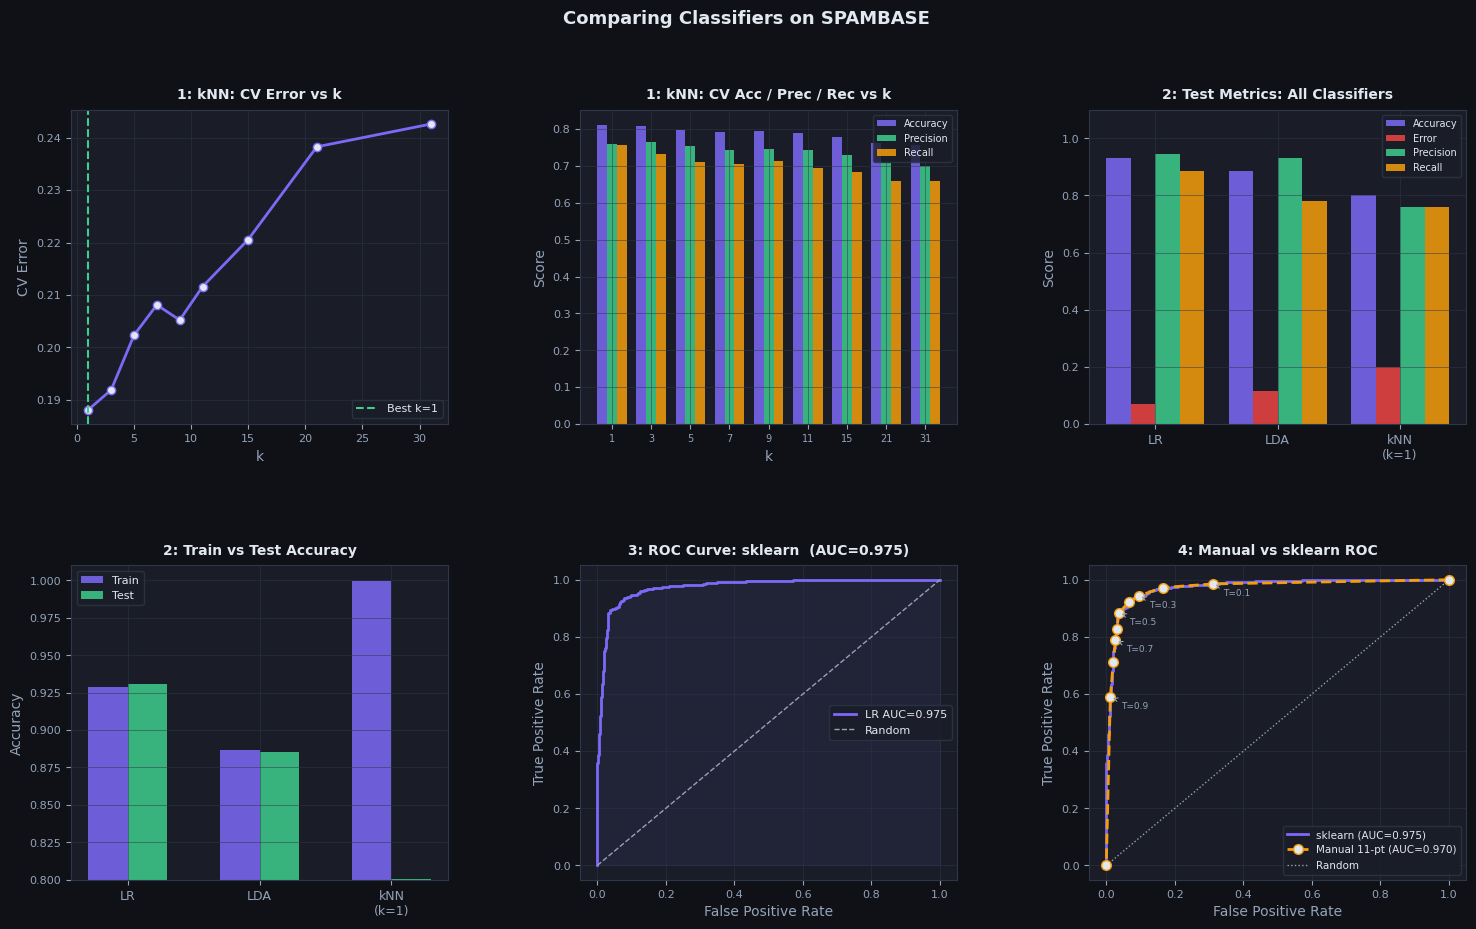

In [45]:
#plotting
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

DARK   = '#0f1117'
PANEL  = '#1a1d27'
ACCENT = '#7c6af7'
GREEN  = '#3ecf8e'
ORANGE = '#f59e0b'
RED    = '#ef4444'
TEXT   = '#e2e8f0'
MUTED  = '#94a3b8'
GRID   = '#2d3748'

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.set_title(title, color=TEXT, fontsize=10, fontweight='bold', pad=8)
    ax.grid(True, color=GRID, linewidth=0.5, alpha=0.7)

#plot 1: CV error vs k
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, "1: kNN: CV Error vs k")
cv_errors = [cv_results[k][1] for k in k_values]
ax1.plot(k_values, cv_errors, color=ACCENT, linewidth=2, marker='o',
         markersize=6, markerfacecolor=TEXT)
ax1.axvline(best_k, color=GREEN, linestyle='--', linewidth=1.5,
            label=f'Best k={best_k}')
ax1.set_xlabel("k"); ax1.set_ylabel("CV Error")
ax1.legend(fontsize=8, labelcolor=TEXT, facecolor=PANEL, edgecolor=GRID)

#plot 2: CV metrics vs k bar chart
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "1: kNN: CV Acc / Prec / Rec vs k")
x = np.arange(len(k_values))
w = 0.25
accs  = [cv_results[k][0] for k in k_values]
precs = [cv_results[k][2] for k in k_values]
recs  = [cv_results[k][3] for k in k_values]
ax2.bar(x - w, accs,  w, label='Accuracy',  color=ACCENT,  alpha=0.85)
ax2.bar(x,     precs, w, label='Precision', color=GREEN,   alpha=0.85)
ax2.bar(x + w, recs,  w, label='Recall',    color=ORANGE,  alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(k_values, fontsize=7)
ax2.set_xlabel("k"); ax2.set_ylabel("Score")
ax2.legend(fontsize=7, labelcolor=TEXT, facecolor=PANEL, edgecolor=GRID)

# plot 3: grouped bar, test metrics for all 3 classifiers
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, "2: Test Metrics: All Classifiers")
clf_labels = ["LR", "LDA", f"kNN\n(k={best_k})"]
test_accs  = [all_metrics[n]["test"][0] for n, _ in classifiers]
test_errs  = [all_metrics[n]["test"][1] for n, _ in classifiers]
test_precs = [all_metrics[n]["test"][2] for n, _ in classifiers]
test_recs  = [all_metrics[n]["test"][3] for n, _ in classifiers]
x3 = np.arange(len(clf_labels)); w3 = 0.2
ax3.bar(x3 - 1.5*w3, test_accs,  w3, label='Accuracy',  color=ACCENT,  alpha=0.85)
ax3.bar(x3 - 0.5*w3, test_errs,  w3, label='Error',     color=RED,     alpha=0.85)
ax3.bar(x3 + 0.5*w3, test_precs, w3, label='Precision', color=GREEN,   alpha=0.85)
ax3.bar(x3 + 1.5*w3, test_recs,  w3, label='Recall',    color=ORANGE,  alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(clf_labels, fontsize=9)
ax3.set_ylabel("Score"); ax3.set_ylim(0, 1.1)
ax3.legend(fontsize=7, labelcolor=TEXT, facecolor=PANEL, edgecolor=GRID)

#plot 4: train vs test accuracy comparison
ax4 = fig.add_subplot(gs[1, 0])
style_ax(ax4, "2: Train vs Test Accuracy")
train_accs = [all_metrics[n]["train"][0] for n, _ in classifiers]
x4 = np.arange(len(clf_labels)); w4 = 0.3
ax4.bar(x4 - w4/2, train_accs, w4, label='Train', color=ACCENT, alpha=0.85)
ax4.bar(x4 + w4/2, test_accs,  w4, label='Test',  color=GREEN,  alpha=0.85)
ax4.set_xticks(x4); ax4.set_xticklabels(clf_labels, fontsize=9)
ax4.set_ylabel("Accuracy"); ax4.set_ylim(0.8, 1.01)
ax4.legend(fontsize=8, labelcolor=TEXT, facecolor=PANEL, edgecolor=GRID)

#plot 5: sklearn ROC curve
ax5 = fig.add_subplot(gs[1, 1])
style_ax(ax5, f"3: ROC Curve: sklearn  (AUC={roc_auc:.3f})")
ax5.plot(fpr_sk, tpr_sk, color=ACCENT, linewidth=2, label=f'LR AUC={roc_auc:.3f}')
ax5.plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1, label='Random')
ax5.fill_between(fpr_sk, tpr_sk, alpha=0.08, color=ACCENT)
ax5.set_xlabel("False Positive Rate"); ax5.set_ylabel("True Positive Rate")
ax5.legend(fontsize=8, labelcolor=TEXT, facecolor=PANEL, edgecolor=GRID)

#plot 6: manual vs sklearn ROC overlay
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax6, "4: Manual vs sklearn ROC")
ax6.plot(fpr_sk, tpr_sk, color=ACCENT, linewidth=2, label=f'sklearn (AUC={roc_auc:.3f})', zorder=2)
ax6.plot(manual_fpr, manual_tpr, color=ORANGE, linewidth=2, linestyle='--',
         marker='o', markersize=7, markerfacecolor=TEXT,
         label=f'Manual 11-pt (AUC={manual_auc:.3f})', zorder=3)
ax6.plot([0, 1], [0, 1], color=MUTED, linestyle=':', linewidth=1, label='Random')
ax6.set_xlabel("False Positive Rate"); ax6.set_ylabel("True Positive Rate")
ax6.legend(fontsize=7.5, labelcolor=TEXT, facecolor=PANEL, edgecolor=GRID)

#annotating threshold labels on manual points
for T, fx, ty in zip(manual_thresholds, manual_fpr, manual_tpr):
    if T in [0.1, 0.3, 0.5, 0.7, 0.9]:
        ax6.annotate(f'T={T}', xy=(fx, ty), xytext=(fx+0.03, ty-0.04),
                     fontsize=6.5, color=MUTED,
                     arrowprops=dict(arrowstyle='->', color=MUTED, lw=0.8))

fig.suptitle("Comparing Classifiers on SPAMBASE",
             color=TEXT, fontsize=13, fontweight='bold', y=0.98)
from IPython.display import display
plt.tight_layout()
display(fig)
plt.close()

### Problem 4: Cross Validation

In [46]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


feature_names = []
with open('spambase.names') as f:
    for line in f:
        line = line.strip()
        if not line.startswith('|') and ':' in line and \
                ('continuous' in line or 'nominal' in line):
            feature_names.append(line.split(':')[0].strip())

df = pd.read_csv('spambase.data', header=None)
df.columns = feature_names + ['spam']

X = df[feature_names].values
y = df['spam'].values

#1) custom k-fold cross-validation implementation

def kfold_cross_validation(X, y, model, k, random_state=42):

    """
    Custom k-fold cross-validation.

    Steps:
      a) divide the entire dataset into k partitions of equal size.
      b) run k experiments:in experiment i, train on the other k-1
         partitions and test on partition i (the validation set).
      c) record the validation error for each experiment.
      d) return the per fold errors and the average validation error.

    Parameters:
    X: feature matrix (N x D)
    y: label vector (N,)
    model: sklearn-compatible classifier
    k: number of folds
    random_state: seed for shuffling

    Returns

    fold_errors: list of validation errors, one per fold
    avg_error: mean validation error across all k folds
    """
    N = len(y)

    #a) shuffle indices, then split into k partitions of equal size
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(N)

    #drop evry remainder so every fold is same size
    fold_size  = N // k
    usable     = fold_size * k
    indices    = indices[:usable]

    partitions = [indices[i * fold_size:(i + 1) * fold_size] for i in range(k)]

    fold_errors = []

    #b) running k experiments
    for i in range(k):

      val_idx   = partitions[i]

      train_idx = np.concatenate([partitions[j] for j in range(k) if j != i])

      X_train, y_train = X[train_idx], y[train_idx]
      X_val,   y_val   = X[val_idx],   y[val_idx]

#train and predict
      model.fit(X_train, y_train)
      y_pred = model.predict(X_val)

#c) validation error for this fold
      error = 1.0 - accuracy_score(y_val, y_pred)
      fold_errors.append(error)

#d) computing average validation error
    avg_error = np.mean(fold_errors)
    return fold_errors, avg_error


#part 2: Run CV for Logistic Regression and LDA

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, solver='lbfgs',
                                              random_state=42),
    "LDA":                 LinearDiscriminantAnalysis(),
}

k_values = [5, 10]

results = {}

print("Part 2: k-Fold CV Results")

for model_name, model in models.items():
    results[model_name] = {}
    print(f"\n  [{model_name}]")

    for k in k_values:
        fold_errors, avg_error = kfold_cross_validation(X, y, model, k)

        results[model_name][k] = (fold_errors, avg_error)


        fold_str = "  ".join([f"Fold {i+1}: {e:.4f}" for i, e in
                               enumerate(fold_errors)])
        print(f"\n    k = {k}")
        print(f"      Per-fold errors : {fold_str}")
        print(f"      Avg val. error  : {avg_error:.4f}  "
              f"(Avg val. accuracy: {1 - avg_error:.4f})")

#3) comparison

print("Part 3: Summary and Comparison")

print(f"\n{'Model':<25} {'k=5  Avg Error':>16} {'k=10  Avg Error':>16}")

for model_name in models:
    e5  = results[model_name][5][1]
    e10 = results[model_name][10][1]
    print(f"  {model_name:<23} {e5:>16.4f} {e10:>16.4f}")

#determining the best and worst model
lr_avg  = np.mean([results["Logistic Regression"][k][1] for k in k_values])
lda_avg = np.mean([results["LDA"][k][1] for k in k_values])

better = "Logistic Regression" if lr_avg < lda_avg else "LDA"
worse  = "LDA" if lr_avg < lda_avg else "Logistic Regression"

print(f"""
Observations:
  - logistic regression average error across k=5 and k=10: {lr_avg:.4f}
  - LDA average error across k=5 and k=10: {lda_avg:.4f}

  - Best model: {better}
  - Worst model: {worse}

  - k=5 and k=10 have very similar average errors for each model,
    indicating the estimates are stable and not that sensitive
    to the # of folds.

  - log reg makes no distributional assumptions about the
    features. LDA assumes Gaussian dist features with equal
    covariance across classes, which is an assumption that may not fully hold
    for Spambase's features, which probably explains its slightly higher error.

  - increasing k from 5 to 10 gives each model more training data per
    fold, generally producing just a slightly lower average error
    due to less bias in the estimate.
""")

Part 2: k-Fold CV Results

  [Logistic Regression]

    k = 5
      Per-fold errors : Fold 1: 0.0674  Fold 2: 0.0663  Fold 3: 0.0685  Fold 4: 0.0848  Fold 5: 0.0772
      Avg val. error  : 0.0728  (Avg val. accuracy: 0.9272)

    k = 10
      Per-fold errors : Fold 1: 0.0543  Fold 2: 0.0761  Fold 3: 0.0413  Fold 4: 0.0761  Fold 5: 0.0543  Fold 6: 0.0848  Fold 7: 0.1065  Fold 8: 0.0587  Fold 9: 0.0652  Fold 10: 0.0826
      Avg val. error  : 0.0700  (Avg val. accuracy: 0.9300)

  [LDA]

    k = 5
      Per-fold errors : Fold 1: 0.0978  Fold 2: 0.1054  Fold 3: 0.1152  Fold 4: 0.1315  Fold 5: 0.1152
      Avg val. error  : 0.1130  (Avg val. accuracy: 0.8870)

    k = 10
      Per-fold errors : Fold 1: 0.0913  Fold 2: 0.1152  Fold 3: 0.0870  Fold 4: 0.1196  Fold 5: 0.1000  Fold 6: 0.1283  Fold 7: 0.1500  Fold 8: 0.1152  Fold 9: 0.1174  Fold 10: 0.1109
      Avg val. error  : 0.1135  (Avg val. accuracy: 0.8865)
Part 3: Summary and Comparison

Model                       k=5  Avg Error  k=10